In [1]:
%pip -q install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00


In [2]:
import gc
import json
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50, vit_b_16, ResNet50_Weights, ViT_B_16_Weights
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from google.colab import drive
from IPython.display import display
from tqdm.auto import tqdm

import open_clip

#! Reproducibility and execution device
SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#! Reuse Parts B/C paths without changing their files

drive.mount("/content/drive")
TASK_ROOT = Path("/content/drive/MyDrive/pa1-beyond-iid/task1")
DATA_PATH = TASK_ROOT / "data/stl10_labeled.npz"
FEATURE_DIR = TASK_ROOT / "results/features"
HEAD_DIR = TASK_ROOT / "models/heads"
BASELINE_DIR = TASK_ROOT / "results/clean_baseline"
COLOR_DIR = TASK_ROOT / "results/color_bias"
PATCH_DIR = TASK_ROOT / "results/patch_shuffle"
IMAGE_DIR = PATCH_DIR / "images"
PATCH_FEATURE_DIR = FEATURE_DIR / "patch_shuffle"

for folder in (PATCH_DIR, IMAGE_DIR, PATCH_FEATURE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ["resnet50", "vit_b16", "clip_b32"]
MODEL_ORDER = MODEL_NAMES + ["clip_zero_shot"]
FEATURE_DIMS = {"resnet50": 2048, "vit_b16": 768, "clip_b32": 512}
GRID = 4
IMAGE_SIZE = 224
PATCH_SIZE = IMAGE_SIZE // GRID
FEATURE_BATCH_SIZE = 16

#! Load exactly the official 500-image evaluation subset

with np.load(DATA_PATH, allow_pickle=False) as data:
    test_images = data["test_images"]
    test_labels = data["test_labels"].astype(np.int64)
    test_indices = data["test_indices"].astype(np.int64)
    CLASS_NAMES = data["class_names"].tolist()

baseline_ids = np.load(BASELINE_DIR / "clean_image_ids.npy", allow_pickle=False)

if (len(test_indices) != 500 or len(CLASS_NAMES) != 10
    or not np.array_equal(test_indices, baseline_ids)):
    raise ValueError("Image IDs or classes differ from Part C.")

required = ([HEAD_DIR / f"{name}_head.pt" for name in MODEL_NAMES]
            + [BASELINE_DIR / f"{name}_clean_predictions.npz" for name in MODEL_ORDER]
            + [FEATURE_DIR / "clip_zeroshot.pt"])

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError(f"Missing Part B/C files: {missing}")

#! Freeze the experiment protocol before inspecting new predictions
plan = {
    "experiment": "Task 1 Part G - Patch Structure",
    "seed": SEED,
    "dataset": "STL-10, the identical 500-image Part C official test subset",
    "common_pixels": "RGB, PIL bicubic resize to 224x224 before any backbone normalization",
    "grid": [4, 4],
    "patch_size_pixels": [56, 56],
    "permutation": "one per image, NumPy default_rng(6304), output block -> original block, non-identity",
    "same_shuffled_pixels_for_all_models": True,
    "primary_metrics": ["accuracy", "accuracy_drop_pp", "prediction_consistency"],
    "additional_metrics": ["macro_f1", "mean_max_confidence"],
    "hypothesis_for_planning_only": "Rearranging 16 blocks may reduce accuracy and consistency; compare to each model's own clean baseline, without assuming architecture rankings."
}

config_path = PATCH_DIR / "experiment_config.json"

if config_path.is_file():
    with open(config_path) as f:
        if json.load(f) != plan:
            raise ValueError("Saved patch-shuffle protocol differs. Inspect before overwriting.")
else:
    with open(config_path, "w") as f:
        json.dump(plan, f, indent=2)

print("Device:", DEVICE)
print("Evaluation images:", len(test_indices))
print("Grid:", GRID, "x", GRID, "block size:", PATCH_SIZE, "x", PATCH_SIZE)
print("Results:", PATCH_DIR)

Mounted at /content/drive
Device: cuda
Evaluation images: 500
Grid: 4 x 4 block size: 56 x 56
Results: /content/drive/MyDrive/pa1-beyond-iid/task1/results/patch_shuffle


In [3]:
#! Reuse compatible Part F pixels, or construct the identical Part B resize
canonical_path = IMAGE_DIR / "canonical_224.pt"
translation_canonical = TASK_ROOT / "results/translation/images/canonical_224.pt"

if not canonical_path.is_file():
    reused = False

    if translation_canonical.is_file():
        old = torch.load(translation_canonical, map_location="cpu", weights_only=True)
        reused = (old["images"].shape == (500, 3, IMAGE_SIZE, IMAGE_SIZE)
                  and old["images"].dtype == torch.uint8
                  and np.array_equal(old["indices"].numpy(), test_indices)
                  and np.array_equal(old["labels"].numpy(), test_labels)
                  and old["seed"] == SEED)

        if reused:
            shutil.copy2(translation_canonical, canonical_path)
            print("Reused Part F canonical images.")
        del old

    if not reused:
        images_224 = torch.empty((500, 3, IMAGE_SIZE, IMAGE_SIZE), dtype=torch.uint8)
        for i in tqdm(range(500), desc="Canonical bicubic resize"):
            image = Image.fromarray(np.transpose(test_images[i], (1, 2, 0))).convert("RGB")
            image = TF.resize(image, [IMAGE_SIZE, IMAGE_SIZE],
                              interpolation=InterpolationMode.BICUBIC)
            images_224[i] = torch.from_numpy(np.asarray(image, dtype=np.uint8).copy()).permute(2, 0, 1)
        torch.save({
            "images": images_224,
            "indices": torch.from_numpy(test_indices.copy()),
            "labels": torch.from_numpy(test_labels.copy()),
            "seed": SEED,
            "size": IMAGE_SIZE
        }, canonical_path)
        del images_224

saved = torch.load(canonical_path, map_location="cpu", weights_only=True)

if (saved["images"].shape != (500, 3, 224, 224)
    or saved["images"].dtype != torch.uint8
    or not np.array_equal(saved["indices"].numpy(), test_indices)
    or not np.array_equal(saved["labels"].numpy(), test_labels)
    or saved["seed"] != SEED):
    raise ValueError("Cached canonical pixels do not match Part C test images.")
canonical_images = saved["images"]

#! Exactly one seeded, non-identity patch permutation per image
rng = np.random.default_rng(SEED)
identity = np.arange(GRID * GRID)
permutations = np.empty((500, GRID * GRID), dtype=np.int64)

for i in range(500):
    perm = rng.permutation(GRID * GRID)
    while np.array_equal(perm, identity):
        perm = rng.permutation(GRID * GRID)
    permutations[i] = perm

manifest = pd.DataFrame({
    "image_id": test_indices,
    "true_label": test_labels,
    **{f"output_patch_{j:02d}_source": permutations[:, j]
       for j in range(GRID * GRID)}
})
manifest_path = PATCH_DIR / "permutation_manifest.csv"

if manifest_path.is_file():
    old_manifest = pd.read_csv(manifest_path)
    if not old_manifest.equals(manifest):
        raise ValueError("Existing permutation manifest differs; do not overwrite it.")
else:
    manifest.to_csv(manifest_path, index=False)

print("Canonical cache:", canonical_path)
print("Permutations frozen:", manifest_path)
display(manifest.head(3))

Reused Part F canonical images.
Canonical cache: /content/drive/MyDrive/pa1-beyond-iid/task1/results/patch_shuffle/images/canonical_224.pt
Permutations frozen: /content/drive/MyDrive/pa1-beyond-iid/task1/results/patch_shuffle/permutation_manifest.csv


,image_id,true_label,output_patch_00_source,output_patch_01_source,output_patch_02_source,output_patch_03_source,output_patch_04_source,output_patch_05_source,output_patch_06_source,output_patch_07_source,output_patch_08_source,output_patch_09_source,output_patch_10_source,output_patch_11_source,output_patch_12_source,output_patch_13_source,output_patch_14_source,output_patch_15_source
0,3,0,15,0,10,5,9,1,3,12,2,13,11,8,6,7,14,4
1,29,7,8,7,3,11,12,5,10,1,9,2,13,0,15,4,6,14
2,35,2,1,10,15,6,11,14,2,0,4,7,12,3,13,8,9,5


In [4]:
#! Split into 16 blocks, choose per-image source blocks, then stitch back

def split_blocks(images):
    n, channels, height, width = images.shape

    if height != IMAGE_SIZE or width != IMAGE_SIZE:
        raise ValueError("Patch shuffle expects canonical 224x224 images.")

    return (images.reshape(n, channels, GRID, PATCH_SIZE, GRID, PATCH_SIZE)
            .permute(0, 2, 4, 1, 3, 5)
            .reshape(n, GRID * GRID, channels, PATCH_SIZE, PATCH_SIZE))


def assemble_blocks(blocks):
    n, _, channels, _, _ = blocks.shape

    return (blocks.reshape(n, GRID, GRID, channels, PATCH_SIZE, PATCH_SIZE)
            .permute(0, 3, 1, 4, 2, 5)
            .reshape(n, channels, IMAGE_SIZE, IMAGE_SIZE))


#! Verify the shuffled cache is tied to the exact frozen per-image manifest
shuffle_path = IMAGE_DIR / "shuffled_4x4.pt"

if not shuffle_path.is_file():
    blocks = split_blocks(canonical_images)
    row_ids = torch.arange(len(test_indices))[:, None]
    output_blocks = blocks[row_ids, torch.from_numpy(permutations)]
    shuffled_images = assemble_blocks(output_blocks)

    #! No interpolation: undoing each permutation must recover original pixels
    inverse = torch.from_numpy(np.argsort(permutations, axis=1))

    for idx in (0, 100, 499):
        restored = assemble_blocks(output_blocks[idx:idx + 1][:, inverse[idx]])
        if not torch.equal(restored, canonical_images[idx:idx + 1]):
            raise RuntimeError(f"Patch reconstruction failed on image {idx}.")

    torch.save({
        "images": shuffled_images,
        "indices": torch.from_numpy(test_indices.copy()),
        "labels": torch.from_numpy(test_labels.copy()),
        "permutations": torch.from_numpy(permutations.copy()),
        "seed": SEED,
        "grid": GRID,
        "patch_size": PATCH_SIZE
    }, shuffle_path)

    del blocks, output_blocks, shuffled_images

saved_shuffle = torch.load(shuffle_path, map_location="cpu", weights_only=True)

if (saved_shuffle["images"].shape != (500, 3, 224, 224)
    or saved_shuffle["images"].dtype != torch.uint8
    or not np.array_equal(saved_shuffle["indices"].numpy(), test_indices)
    or not np.array_equal(saved_shuffle["labels"].numpy(), test_labels)
    or not np.array_equal(saved_shuffle["permutations"].numpy(), permutations)
    or saved_shuffle["seed"] != SEED):

    raise ValueError("Cached shuffled images are incompatible with the current protocol.")

shuffled_images = saved_shuffle["images"]

print("Shuffled image cache:", shuffle_path)
print("Shape:", tuple(shuffled_images.shape))
print("All models will reuse this single shuffled tensor.")

Shuffled image cache: /content/drive/MyDrive/pa1-beyond-iid/task1/results/patch_shuffle/images/shuffled_4x4.pt
Shape: (500, 3, 224, 224)
All models will reuse this single shuffled tensor.


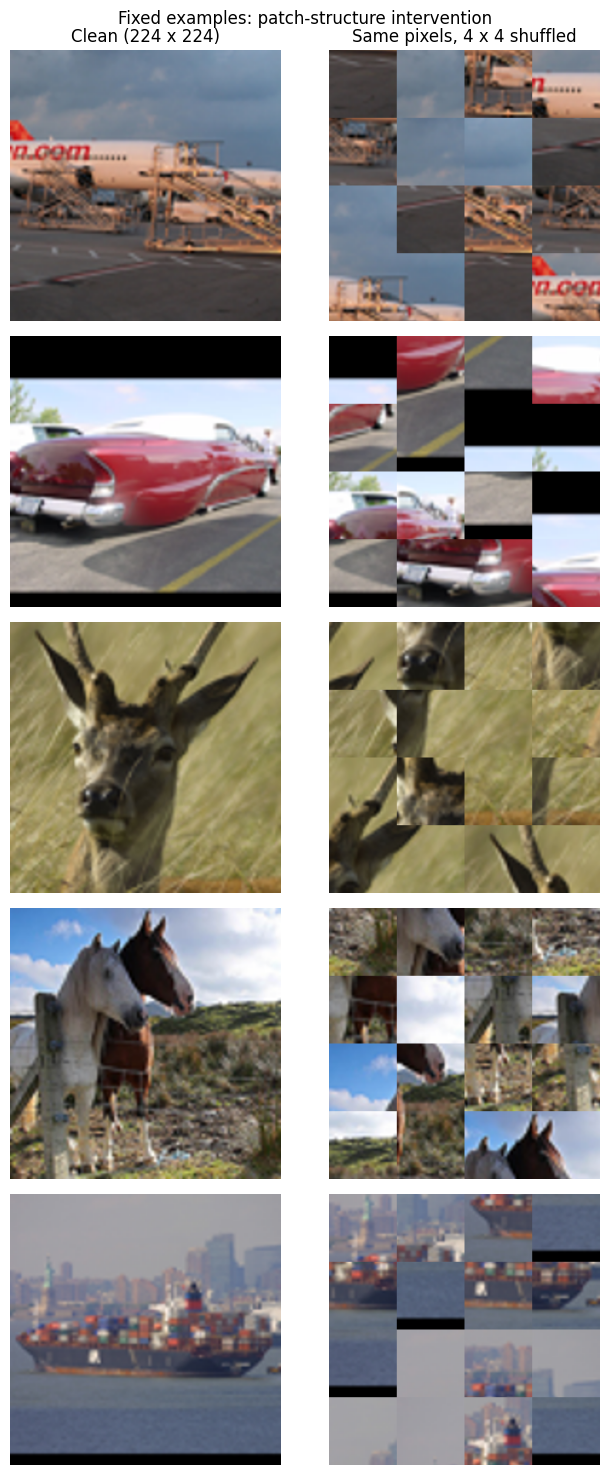

Saved example figure and fixed image IDs.


In [5]:
#! Select image examples by fixed class IDs, not by model performance
example_classes = [0, 2, 4, 6, 8]

positions = [int(np.flatnonzero(test_labels == c)[0]) for c in example_classes]
example_rows = []

fig, axes = plt.subplots(len(positions), 2, figsize=(7, 15))

for row, idx in enumerate(positions):
    axes[row, 0].imshow(canonical_images[idx].permute(1, 2, 0).numpy())
    axes[row, 1].imshow(shuffled_images[idx].permute(1, 2, 0).numpy())
    axes[row, 0].set_ylabel(CLASS_NAMES[int(test_labels[idx])])

    for ax in axes[row]:
        ax.axis("off")

    example_rows.append({
        "image_id": int(test_indices[idx]),
        "true_class": CLASS_NAMES[int(test_labels[idx])],
        "subset_position": idx
    })

axes[0, 0].set_title("Clean (224 x 224)")
axes[0, 1].set_title("Same pixels, 4 x 4 shuffled")

fig.suptitle("Fixed examples: patch-structure intervention")
fig.tight_layout()
fig.savefig(PATCH_DIR / "patch_shuffle_examples.png", dpi=250, bbox_inches="tight")

plt.show()

pd.DataFrame(example_rows).to_csv(PATCH_DIR / "example_image_ids.csv", index=False)

print("Saved example figure and fixed image IDs.")

In [6]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)

#! Match the exact pretrained backbones and feature extraction in Part B

def load_backbone(model_name):
    if model_name == "resnet50":
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        backbone.fc = nn.Identity()
    elif model_name == "vit_b16":
        backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        backbone.heads = nn.Identity()
    elif model_name == "clip_b32":
        backbone, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
    else:
        raise ValueError(f"Unknown backbone: {model_name}")

    for parameter in backbone.parameters():
        parameter.requires_grad = False

    return backbone.to(DEVICE).eval()


@torch.inference_mode()

def extract_patch_features(backbone, model_name):
    loader = DataLoader(TensorDataset(shuffled_images), batch_size=FEATURE_BATCH_SIZE,
                        shuffle=False, num_workers=0, pin_memory=(DEVICE.type == "cuda"))

    mean_values, std_values = ((CLIP_MEAN, CLIP_STD) if model_name == "clip_b32"
                               else (IMAGENET_MEAN, IMAGENET_STD))

    mean = torch.tensor(mean_values, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
    std = torch.tensor(std_values, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
    outputs = []

    for (images,) in tqdm(loader, desc=f"Extracting {model_name} shuffled features"):
        images = images.to(DEVICE, non_blocking=True).float().div(255.0)
        images = (images - mean) / std

        if model_name == "clip_b32":
            features = F.normalize(backbone.encode_image(images).float(), p=2, dim=-1)
        else:
            features = backbone(images).float()
        outputs.append(features.cpu())
    return torch.cat(outputs, dim=0).float()


#! Extract only missing features; never retrain the classification heads
for model_name in MODEL_NAMES:
    path = PATCH_FEATURE_DIR / f"{model_name}_patch_shuffle.pt"

    if path.is_file():
        old = torch.load(path, map_location="cpu", weights_only=True)

        if (old["features"].shape != (500, FEATURE_DIMS[model_name])
            or not np.array_equal(old["indices"].numpy(), test_indices)
            or not np.array_equal(old["labels"].numpy(), test_labels)
            or not np.array_equal(old["permutations"].numpy(), permutations)
            or old["seed"] != SEED):
            raise ValueError(f"Incompatible saved shuffled features: {path}")

        print("Reusing:", path.name)
        del old
        continue

    backbone = load_backbone(model_name)
    features = extract_patch_features(backbone, model_name)

    if features.shape != (500, FEATURE_DIMS[model_name]) or not torch.isfinite(features).all():
        raise RuntimeError(f"Invalid extracted features: {model_name}")

    torch.save({
        "features": features,
        "indices": torch.from_numpy(test_indices.copy()),
        "labels": torch.from_numpy(test_labels.copy()),
        "permutations": torch.from_numpy(permutations.copy()),
        "seed": SEED,
        "condition": "patch_shuffle_4x4"
    }, path)

    print("Saved:", path.name)
    del backbone, features
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("All three transformed feature caches are ready for Part H.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s]


Extracting resnet50 shuffled features:   0%|          | 0/32 [00:00<?, ?it/s]

Saved: resnet50_patch_shuffle.pt
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 96.5MB/s]


...

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Extracting clip_b32 shuffled features:   0%|          | 0/32 [00:00<?, ?it/s]

Saved: clip_b32_patch_shuffle.pt
All three transformed feature caches are ready for Part H.


In [7]:
#! Load clean baselines in the same 500-image order

clean_data = {}

for model_name in MODEL_ORDER:
    with np.load(BASELINE_DIR / f"{model_name}_clean_predictions.npz", allow_pickle=False) as data:

        if (not np.array_equal(data["image_ids"], test_indices)
            or not np.array_equal(data["y_true"], test_labels)):
            raise ValueError(f"Clean predictions are misaligned: {model_name}")

        clean_data[model_name] = data["y_pred"].astype(np.int64).copy()

#! Fixed zero-shot CLIP class order and already-exponentiated temperature
zero_shot = torch.load(FEATURE_DIR / "clip_zeroshot.pt", map_location="cpu", weights_only=True)
text_features = zero_shot["text_features"].float()
logit_scale = float(zero_shot["logit_scale"])  #! Already exp(logit_scale)
expected_prompts = [f"a photo of a {name}." for name in CLASS_NAMES]

if zero_shot["class_names"] != CLASS_NAMES or zero_shot["prompts"] != expected_prompts:
    raise ValueError("Zero-shot class or prompt order differs from Part B.")

summary_rows = []
prediction_rows = []


def evaluate_model(model_name, logits):
    clean_pred = clean_data[model_name]

    with torch.inference_mode():
        probabilities = torch.softmax(logits.float(), dim=1)
        confidence, predicted = probabilities.max(dim=1)

    y_pred = predicted.cpu().numpy().astype(np.int64)
    probs = probabilities.cpu().numpy()
    conf = confidence.cpu().numpy()
    clean_accuracy = float(accuracy_score(test_labels, clean_pred))
    accuracy = float(accuracy_score(test_labels, y_pred))
    consistency = float(np.mean(y_pred == clean_pred))

    np.savez_compressed(
        PATCH_DIR / f"{model_name}_patch_predictions.npz",
        image_ids=test_indices, y_true=test_labels, y_pred=y_pred,
        clean_y_pred=clean_pred, logits=logits.cpu().numpy(), probabilities=probs,
        max_confidence=conf, correct=(y_pred == test_labels),
        prediction_changed=(y_pred != clean_pred), seed=np.int64(SEED)
    )

    pd.DataFrame(confusion_matrix(test_labels, y_pred, labels=list(range(10))),
                 index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
                     PATCH_DIR / f"{model_name}_confusion.csv", index_label="true/predicted")
    per_class = []

    for class_id, class_name in enumerate(CLASS_NAMES):
        mask = test_labels == class_id
        per_class.append({
            "class_name": class_name, "support": int(mask.sum()),
            "clean_accuracy": float(np.mean(clean_pred[mask] == test_labels[mask])),
            "shuffled_accuracy": float(np.mean(y_pred[mask] == test_labels[mask]))
        })

    pd.DataFrame(per_class).to_csv(PATCH_DIR / f"{model_name}_per_class.csv", index=False)

    summary_rows.append({
        "model": model_name, "n_images": 500, "clean_accuracy": clean_accuracy,
        "accuracy": accuracy, "accuracy_drop_pp": 100 * (clean_accuracy - accuracy),
        "accuracy_change_pp": 100 * (accuracy - clean_accuracy),
        "prediction_consistency": consistency, "n_changed": int(np.sum(y_pred != clean_pred)),
        "n_correct": int(np.sum(y_pred == test_labels)),
        "macro_f1": float(f1_score(test_labels, y_pred, labels=list(range(10)),
                                   average="macro", zero_division=0)),
        "mean_max_confidence": float(conf.mean()), "seed": SEED
    })

    prediction_rows.extend({
        "image_id": int(test_indices[i]), "model": model_name,
        "true_label": int(test_labels[i]), "clean_prediction": int(clean_pred[i]),
        "shuffled_prediction": int(y_pred[i]),
        "prediction_changed": bool(y_pred[i] != clean_pred[i]),
        "correct": bool(y_pred[i] == test_labels[i]), "max_confidence": float(conf[i])
    } for i in range(500))

    print(f"{model_name}: clean={clean_accuracy:.4f}, shuffled={accuracy:.4f}, "
          f"drop={100 * (clean_accuracy - accuracy):+.2f} pp, consistency={consistency:.4f}")


#! Load each trained head once; one CLIP image-feature set powers both CLIP configurations
for model_name in MODEL_NAMES:
    checkpoint = torch.load(HEAD_DIR / f"{model_name}_head.pt", map_location="cpu", weights_only=True)

    if checkpoint["model_name"] != model_name or checkpoint["seed"] != SEED:
        raise ValueError(f"Incorrect classifier checkpoint: {model_name}")

    head = nn.Linear(checkpoint["in_features"], checkpoint["num_classes"])
    head.load_state_dict(checkpoint["head_state_dict"])
    head.eval()

    saved = torch.load(PATCH_FEATURE_DIR / f"{model_name}_patch_shuffle.pt",
                       map_location="cpu", weights_only=True)

    if not np.array_equal(saved["indices"].numpy(), test_indices):
        raise ValueError(f"Misaligned shuffled features: {model_name}")

    with torch.inference_mode():
        logits = head(saved["features"].float())
    evaluate_model(model_name, logits)

    if model_name == "clip_b32":
        clip_images = saved["features"].float()

        if (not torch.allclose(clip_images.norm(dim=1), torch.ones(500), atol=1e-3)
            or text_features.shape != (10, 512)):
            raise ValueError("CLIP embeddings are not normalized or have wrong dimensions.")

        with torch.inference_mode():
            zero_logits = logit_scale * (clip_images @ text_features.T)
        evaluate_model("clip_zero_shot", zero_logits)
    del head, checkpoint, saved

#! Save both aggregate and paired per-image evidence
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(PATCH_DIR / "summary.csv", index=False)
pd.DataFrame(prediction_rows).to_csv(PATCH_DIR / "predictions.csv", index=False)

with open(PATCH_DIR / "summary.json", "w") as f:
    json.dump({"seed": SEED, "n_images": 500, "grid": [4, 4], "results": summary_rows}, f, indent=2)

print("\nPATCH STRUCTURE RESULTS")
display(summary_df.round(4))

resnet50: clean=0.9760, shuffled=0.8940, drop=+8.20 pp, consistency=0.9140
vit_b16: clean=0.9740, shuffled=0.9040, drop=+7.00 pp, consistency=0.9060
clip_b32: clean=0.9800, shuffled=0.8100, drop=+17.00 pp, consistency=0.8140
clip_zero_shot: clean=0.9680, shuffled=0.8100, drop=+15.80 pp, consistency=0.8100

PATCH STRUCTURE RESULTS


,model,n_images,clean_accuracy,accuracy,accuracy_drop_pp,accuracy_change_pp,prediction_consistency,n_changed,n_correct,macro_f1,mean_max_confidence,seed
0,resnet50,500,0.976,0.894,8.2,-8.2,0.914,43,447,0.8942,0.8923,6304
1,vit_b16,500,0.974,0.904,7.0,-7.0,0.906,47,452,0.9033,0.9091,6304
2,clip_b32,500,0.980,0.810,17.0,-17.0,0.814,93,405,0.8094,0.1718,6304
3,clip_zero_shot,500,0.968,0.810,15.8,-15.8,0.810,95,405,0.8095,0.7731,6304


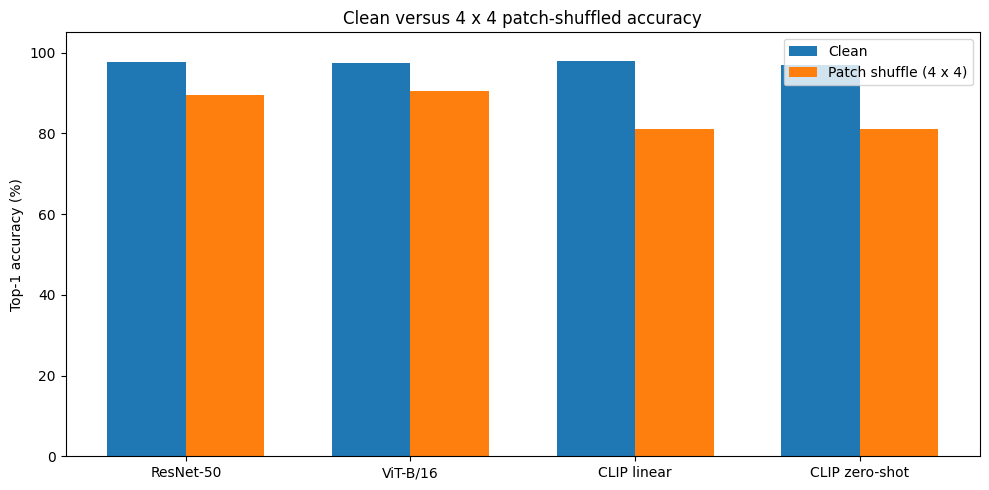

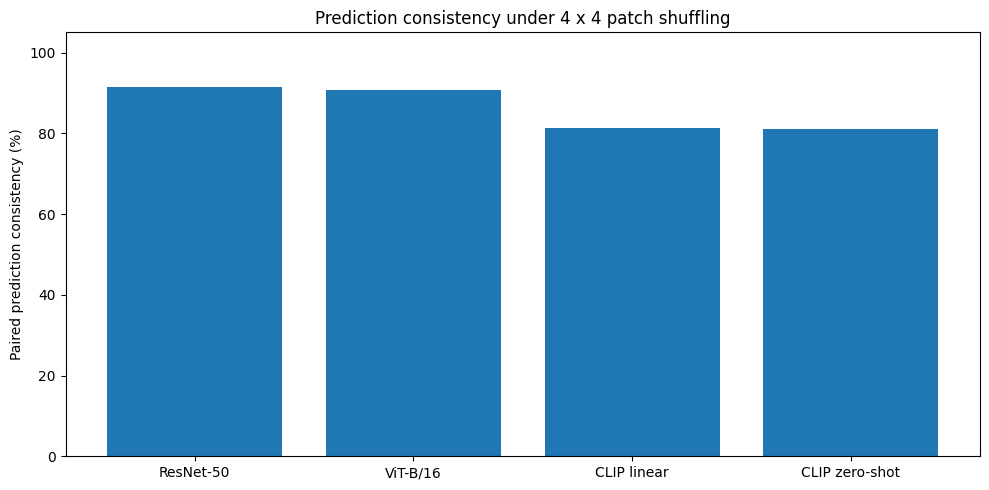

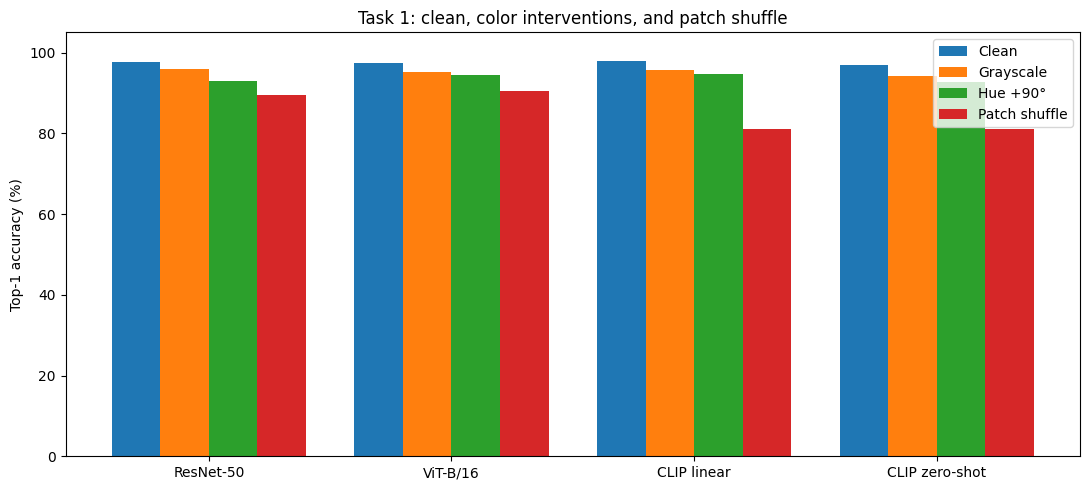

Saved four-condition comparison CSV and figure.
Saved patch-structure figures.


In [8]:
#! Clean versus patch-shuffled accuracy (no forced model ranking)
labels = ["ResNet-50", "ViT-B/16", "CLIP linear", "CLIP zero-shot"]
plot_df = summary_df.set_index("model").loc[MODEL_ORDER]

x = np.arange(len(MODEL_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width / 2, 100 * plot_df.clean_accuracy, width, label="Clean")
ax.bar(x + width / 2, 100 * plot_df.accuracy, width, label="Patch shuffle (4 x 4)")
ax.set_xticks(x, labels)
ax.set_ylim(0, 105)
ax.set_ylabel("Top-1 accuracy (%)")
ax.set_title("Clean versus 4 x 4 patch-shuffled accuracy")
ax.legend()

fig.tight_layout()
fig.savefig(PATCH_DIR / "patch_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

#! Consistency compares each transformed prediction with the same image's clean prediction
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x, 100 * plot_df.prediction_consistency)
ax.set_xticks(x, labels)
ax.set_ylim(0, 105)
ax.set_ylabel("Paired prediction consistency (%)")
ax.set_title("Prediction consistency under 4 x 4 patch shuffling")

fig.tight_layout()
fig.savefig(PATCH_DIR / "patch_consistency.png", dpi=300, bbox_inches="tight")

plt.show()

#! Merge exact saved results from Parts C, D and G when Part D has finished
color_path = COLOR_DIR / "summary.csv"

if color_path.is_file():
    color_df = pd.read_csv(color_path)
    conditions = ["clean", "grayscale", "hue90", "patch_shuffle"]
    comparison_rows = []

    for name in MODEL_ORDER:
        clean_acc = float(plot_df.loc[name, "clean_accuracy"])
        comparison_rows.append({"model": name, "condition": "clean", "accuracy": clean_acc,
                                "accuracy_change_pp": 0.0, "prediction_consistency": 1.0})

        for cond in ("grayscale", "hue90"):
            match = color_df.loc[(color_df.model == name) & (color_df.condition == cond)]

            if len(match) != 1:
                raise ValueError(f"Color bias output is incomplete for {name}/{cond}.")
            row = match.iloc[0]

            comparison_rows.append({"model": name, "condition": cond,
                                    "accuracy": float(row.accuracy),
                                    "accuracy_change_pp": 100 * (float(row.accuracy) - clean_acc),
                                    "prediction_consistency": float(row.prediction_consistency)})

        patch_row = plot_df.loc[name]
        comparison_rows.append({"model": name, "condition": "patch_shuffle",
                                "accuracy": float(patch_row.accuracy),
                                "accuracy_change_pp": float(patch_row.accuracy_change_pp),
                                "prediction_consistency": float(patch_row.prediction_consistency)})

    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df.to_csv(PATCH_DIR / "clean_color_patch_comparison.csv", index=False)
    fig, ax = plt.subplots(figsize=(11, 5))
    width = 0.20

    for offset, cond, label in [(-1.5, "clean", "Clean"), (-0.5, "grayscale", "Grayscale"),
                                (0.5, "hue90", "Hue +90°"), (1.5, "patch_shuffle", "Patch shuffle")]:
        values = [comparison_df.loc[(comparison_df.model == model) &
                                    (comparison_df.condition == cond), "accuracy"].iloc[0]
                  for model in MODEL_ORDER]
        ax.bar(x + offset * width, np.asarray(values) * 100, width, label=label)

    ax.set_xticks(x, labels)
    ax.set_ylim(0, 105)
    ax.set_ylabel("Top-1 accuracy (%)")
    ax.set_title("Task 1: clean, color interventions, and patch shuffle")
    ax.legend()

    fig.tight_layout()
    fig.savefig(PATCH_DIR / "clean_color_patch_comparison.png", dpi=300, bbox_inches="tight")

    plt.show()
    print("Saved four-condition comparison CSV and figure.")
else:
    print("Part D summary.csv is not available yet; optional four-condition comparison skipped.")

print("Saved patch-structure figures.")

In [9]:
#! Check saved files for future report writing and representation analysis

required_files = [
    PATCH_DIR / "experiment_config.json",
    PATCH_DIR / "permutation_manifest.csv",
    PATCH_DIR / "example_image_ids.csv",
    PATCH_DIR / "patch_shuffle_examples.png",
    PATCH_DIR / "summary.csv",
    PATCH_DIR / "summary.json",
    PATCH_DIR / "predictions.csv",
    PATCH_DIR / "patch_accuracy.png",
    PATCH_DIR / "patch_consistency.png",
    IMAGE_DIR / "canonical_224.pt",
    IMAGE_DIR / "shuffled_4x4.pt"
]

required_files.extend(PATCH_FEATURE_DIR / f"{name}_patch_shuffle.pt" for name in MODEL_NAMES)
required_files.extend(PATCH_DIR / f"{name}_patch_predictions.npz" for name in MODEL_ORDER)
required_files.extend(PATCH_DIR / f"{name}_confusion.csv" for name in MODEL_ORDER)
required_files.extend(PATCH_DIR / f"{name}_per_class.csv" for name in MODEL_ORDER)

if (COLOR_DIR / "summary.csv").is_file():
    required_files.extend([PATCH_DIR / "clean_color_patch_comparison.csv",
                           PATCH_DIR / "clean_color_patch_comparison.png"])

missing = [str(path) for path in required_files if not path.is_file()]

if missing:
    raise FileNotFoundError(f"Missing Part G files: {missing}")

saved_manifest = pd.read_csv(PATCH_DIR / "permutation_manifest.csv")
saved_summary = pd.read_csv(PATCH_DIR / "summary.csv")

if (len(saved_manifest) != 500 or len(saved_summary) != 4
    or not np.array_equal(saved_manifest.image_id.to_numpy(), test_indices)):
    raise ValueError("Saved patch manifest or result table is incomplete.")

#! Recalculate the three required metrics using stored paired predictions
for model_name in MODEL_ORDER:

    with np.load(PATCH_DIR / f"{model_name}_patch_predictions.npz", allow_pickle=False) as saved:

        if not np.array_equal(saved["image_ids"], test_indices):
            raise ValueError(f"Wrong image IDs for {model_name}.")

        patch_pred = saved["y_pred"]
        clean_pred = saved["clean_y_pred"]
        clean_acc = float(np.mean(clean_pred == test_labels))
        patch_acc = float(np.mean(patch_pred == test_labels))
        paired = float(np.mean(clean_pred == patch_pred))
        row = saved_summary.loc[saved_summary.model == model_name].iloc[0]

        if (not np.isclose(row.accuracy, patch_acc)
            or not np.isclose(row.accuracy_drop_pp, 100 * (clean_acc - patch_acc))
            or not np.isclose(row.prediction_consistency, paired)):
            raise ValueError(f"Saved metrics disagree with predictions for {model_name}.")

        print(f"{model_name}: 500 paired predictions verified")

print("\nPART G COMPLETE — verified files:", len(required_files))
print("Results:", PATCH_DIR)

display(saved_summary.round(4))

resnet50: 500 paired predictions verified
vit_b16: 500 paired predictions verified
clip_b32: 500 paired predictions verified
clip_zero_shot: 500 paired predictions verified

PART G COMPLETE — verified files: 28
Results: /content/drive/MyDrive/pa1-beyond-iid/task1/results/patch_shuffle


,model,n_images,clean_accuracy,accuracy,accuracy_drop_pp,accuracy_change_pp,prediction_consistency,n_changed,n_correct,macro_f1,mean_max_confidence,seed
0,resnet50,500,0.976,0.894,8.2,-8.2,0.914,43,447,0.8942,0.8923,6304
1,vit_b16,500,0.974,0.904,7.0,-7.0,0.906,47,452,0.9033,0.9091,6304
2,clip_b32,500,0.980,0.810,17.0,-17.0,0.814,93,405,0.8094,0.1718,6304
3,clip_zero_shot,500,0.968,0.810,15.8,-15.8,0.810,95,405,0.8095,0.7731,6304
